In [45]:
import itertools
from collections import Counter
import matplotlib.pyplot as plt
import random 
def dice_distribution(dice_list, plot=True):
    """
    dice_list: [6,6] → два шестигранника
               [4,8,12] → три кубика
    """

    # диапазоны значений для каждого кубика
    dice_ranges = [range(1, sides + 1) for sides in dice_list]

    # все возможные комбинации
    all_rolls = itertools.product(*dice_ranges)

    # распределение сумм
    sums = [sum(roll) for roll in all_rolls]
    distribution = Counter(sums)

    # ==========================
    #   Перенумерация dict с 1
    # ==========================
    real_x_vals = sorted(distribution.keys())
    y_vals = [distribution[x] for x in real_x_vals]

    fake_distribution = {i + 1: y_vals[i] for i in range(len(y_vals))}

    if plot:
        total = sum(y_vals)

        # --- Кумулятивный процент ---
        cumulative = []
        running_sum = 0
        for y in y_vals:
            running_sum += y
            cumulative.append(running_sum / total * 100)

        # --- X начиная с 1 ---
        fake_x_vals = list(range(1, len(real_x_vals) + 1))

        plt.figure(figsize=(14, 7))
        plt.bar(fake_x_vals, y_vals)

        plt.xlabel("Номер столбика (старт с 1)")
        plt.ylabel("Количество комбинаций")
        plt.title(f"Распределение сумм для кубиков {dice_list}")

        # Все тики на оси X
        plt.xticks(fake_x_vals)

        # Кума
        for x, cum in zip(fake_x_vals, cumulative):
            plt.text(x, y_vals[x - 1], f"{cum:.1f}%", ha="center", va="bottom")

        #plt.tight_layout()
        #plt.show()

        # Мода (по реальным суммам)
        mode = max(distribution, key=distribution.get)
        print("Мода:", mode)

    return fake_distribution


In [65]:
for i in [0.1,0.2,0.3,0.5,0.7]:
    print(100*0.6*i)

6.0
12.0
18.0
30.0
42.0


In [70]:
размер 4 6 8
укрытие 4 6 8 10

SyntaxError: invalid syntax (1232581175.py, line 1)

In [71]:
4*4

16

Мода: 13


{1: 1,
 2: 3,
 3: 6,
 4: 10,
 5: 15,
 6: 21,
 7: 28,
 8: 36,
 9: 42,
 10: 46,
 11: 48,
 12: 48,
 13: 46,
 14: 42,
 15: 36,
 16: 28,
 17: 21,
 18: 15,
 19: 10,
 20: 6,
 21: 3,
 22: 1}

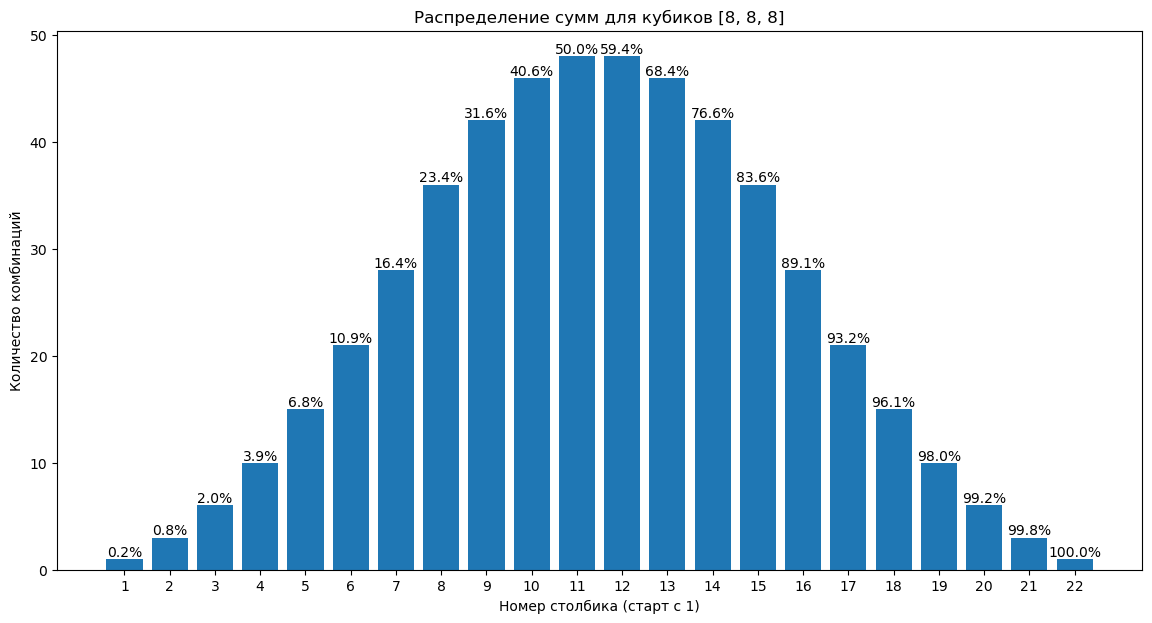

In [75]:
d = 8
dice_distribution([d,d,d])

In [28]:

##### import random
from collections import Counter

results = []

r1 = 60
r2 = 60

# основной цикл
for _ in range(100000):

    # --- t1: сумма 2 кубиков d24 ---
    t1 = random.randint(1, r1)

    # --- t2: сумма 2 кубиков d60 ---
    t2 = random.randint(1, r2)

    # --- отношение t1/t2 округлённое ---
    ratio = t1 / t2

    results.append(ratio)

# --- маппинг в категории ---
def map_category(r):
    if r <= 0.3:
        return "засада"
    elif r < 0.8:
        return "поражение"
    elif r <= 1.25:
        return "ничья"
    elif r < 3.33:
        return "победа"
    else:
        return "разгром"


mapped = [map_category(r) for r in results]

# --- частоты ---
distribution = Counter(mapped)

# --- расчет процентов ---
total = len(results)
percentages = {k: round(v / total * 100, 1) for k, v in distribution.items()}

# вывод красиво
for category in ["засада", "поражение", "ничья", "победа", "разгром"]:
    print(f"{category}: {percentages.get(category, 0)}%")

засада: 14.4%
поражение: 25.1%
ничья: 20.6%
победа: 25.3%
разгром: 14.6%


In [27]:
z , por, n,pob, r

(14498, 25401, 20635, 25095, 14371)

In [12]:
z , por, n,pob, r
(1017, 2013, 1779, 2554, 1408)

(1017, 2013, 1779, 2554, 1408)

In [1]:
import random 

In [174]:
attack_power

0.5

In [173]:
attack_power = 10
attack_power = attack_power*0.05

distance = 4
distance_koef = 1.5
distance = distance_koef*4 - distance*distance_koef

cover = 4
cover_koef = 3.5
cover = cover_koef*4 - cover*cover_koef

power = int(round(3+distance + attack_power + cover,0))

power

4

In [1]:
import random
attack_power - от 6 до 120
distance - от 0 до 4
cover - от 0 до 4



NameError: name 'attack_power' is not defined

In [ ]:
attack_power = 30
distance = 1 
cover = 1 
result = 10

In [ ]:
attack_power = 10
distance = 3 
cover = 3 
result = 5

attack_power = 10
distance = 1 
cover = 1 
result = 7

attack_power = 30
distance = 1 
cover = 1 
result = 10

attack_power = 100
distance = 2
cover = 0
result = 30

attack_power = 100
distance = 0 
cover = 0 
result = 50


In [22]:
final_res = 0
for check in range(20):
    n1 = 30
    res1 = 0
    for i in range(3):
        res1+= random.randint(1,n1)
    
    n2 = 10
    res2 = 0
    for i in range(3):
        res2+= random.randint(1,n2)

    res = res1-res2
    if res <0:
        res = 0
    final_res +=res
    print(res)
print('в среднем', final_res/20)
print(final_res)

40
66
49
35
1
25
20
23
28
17
39
0
60
56
19
38
4
33
26
35
в среднем 30.7
614


In [23]:
import math

def calculate_result(attack_power, distance, cover):
    result = (
        5
        * math.sqrt(attack_power)
        * (0.72 ** distance)
        * (0.75 ** cover)
    )
    return int(round(result))


In [24]:
calculate_result(60, 3, 1)

11